In [1]:
import wget
import os
import healpy as hp
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.optimize import curve_fit

from astropy import units as u, constants as const



def b(nu):
    """
    estimate dI/dT_CMB as defined in eq. 8 of Planck 2013 IX
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2
        * const.h
        * nu ** 3
        / const.c ** 2
        / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    estimate dI/dT_RJ as defined in eq. 30 of Planck 2013 IX
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)

def brightness2Tcmb(nu, bandpass=None):
    """
    Convert from Jy/srad  to K_CMB
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Convert from Jy/srad to K_RJ
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert antenna temperature ( Rayleigh-Jeans) into the physical one
    """
    return Trj / Kcmb2Krj(
        nu=nu, Tcmb=1, bandpass=bandpass
    )  # (x ** 2 * np.exp(x) / (np.exp(x) - 1) ** 2)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )



In [2]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress

def rotate_map(mapin, coord_in , coord_out ) : 
    alm = hp.map2alm (mapin )
    R=  hp.Rotator(coord=[coord_in, coord_out ])
    alm =  R.rotate_alm (alm )
    map_out = hp.alm2map (alm , nside= hp.get_nside(mapin ))
    return map_out


def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """perform linear regression between two data set and get spectral index """

    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2/v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)

    #if beta > -2.1 or beta < -3.5:
    #    plt.plot(xdat, ydat, '.')
    #    plt.plot(xdat, fitted_gradient*xdat +  myoutput.beta[1], 'r-')
    #    plt.show()

    #    print("breaking here")
    
    return beta, beta_error, myoutput 
    
def sform(param, xxx):
    '''linear reggression'''
    return xxx * param[0] + param[1]
def fitting_beta_curvature(X, beta, cs):
   return beta*X +cs*X*X 

def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval


def remove_off(map, hasmap, maperr, haserr, kval):

    if kval > 9000:
        corrmax = 0.0
    else: 
        corrmax = 0.85

    nside_superpix=8
    nan1 =np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)

    try : 
        ang = hp.pix2ang(ipix= pixs[nan1][0] , nside= hp.get_nside(map)) 
        pix1 = hp.ang2pix(theta=ang[0] , phi = ang[1] , nside= nside_superpix)
    

        if pixs[nan1] [0]==0 :
            print("Southern Survey ") 
            super_pixs=  np.arange(pix1, hp.nside2npix(nside_superpix)) 
        else: 
            print("Northern survey ")
            super_pixs=  np.arange(pix1) 
    except IndexError: 
        print('Fullsky survey')
        super_pixs=  np.arange(hp.nside2npix(nside_superpix )) 
    offsets = np.zeros_like(super_pixs)*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)  
   

    nansize =0 
    for jj, ipix in enumerate(super_pixs) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:           
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
        
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > corrmax:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 
            
    offmap[super_pixs] = offsets 

    avec = np.nanmean( offsets ) *map.unit 
    map = map - avec
    if offsets.size - nansize < 2:
        print("Issue")
    o_err = np.nanstd(offsets) /np.sqrt(offsets.size - nansize)
    
    return map, avec, o_err, offmap 
 


https://lambda.gsfc.nasa.gov/product/wmap/dr5/ 

https://lambda.gsfc.nasa.gov/product/foreground/fg_all_sky150_mhzmap_get.html



https://lambda.gsfc.nasa.gov/data/map/dr5/skymaps/9yr/deconv/images/wmap_band_deconv_imap_r9_9yr_K_v5.fits

https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/haslam408_ds_Remazeilles2014.fits

https://lda10g.alliance.unm.edu/LWA1LowFrequencySkySurvey/
https://lambda.gsfc.nasa.gov/data/foregrounds/lwa1/healpix-all-sky-rav-wsclean-map-50.fits

https://lambda.gsfc.nasa.gov/product/foreground/fg_rhodes_hart_info.html


In [3]:
maps={}
mapserr={}
offerr={}

cwd = Path.cwd() 

fstring ="MAIPU_MU_1_64.fits"
try :
    print(f"reading {fstring} ")

    maps[45],_=  hp.read_map(f"../southern_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/maipu_45/{fstring}", out ="../southern_data")
    maps[45]=  hp.read_map(f"../southern_data/{fstring}"  )

maps[45] = hp.ud_grade(maps[45], 256)
maps[45] = rotate_map(maps[45], 'G', 'C')
zeros = maps[45] < 0. 
maps[45][zeros]  =  np.nan  
maps[45]*=u.K
mapserr[45] = 0.07 # 7 per cent for mapu calibration
offerr[45] = 0.0

fstring ="lambda_landecker_wielebinski_150MHz_hpx_r8.fits"
try :
    print(f"reading {fstring} ")

    maps[150],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/landecker_150/{fstring}", out ="../lwa_data")
    maps[150]=  hp.read_map(f"../lwa_data/{fstring}"  )


maps[150 ] = rotate_map(maps[150], 'G', 'C')
maps[150] = (maps[150] * u.K ).to(maps[45].unit )
mapserr[150] = 0.05 # 5 per cent for 150 calibration
offerr[150] = 0.0

fstring="haslam408_ds_Remazeilles2014.fits"

try :
    print(f"reading {fstring} ")

    maps[408],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/{fstring}", out ="../lwa_data")
    maps[408]=  hp.read_map(f"../lwa_data/{fstring}"  )

maps[408 ] = rotate_map(maps[408], 'G', 'C')

maps[408]= (maps[408]*u.K -8.9*u.K ).to(maps[45].unit)
mapserr[408] = np.sqrt((0.1 * maps[408].value)**2 + 1.3**2) /  maps[408].value # 10 per cent for 408 calibration plus the 1.3K offset error
offerr[408] = 0.0 # it has already been added to maperr

# fstring="lambda_chipass_healpix_r10.fits"
# try :
        
#     print(f"reading {fstring} ")

#     maps[1400],_=  hp.read_map(f"../southern_data/{fstring}" ,h=True  )  
# except FileNotFoundError: 
#     filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/chipass/{fstring}", out ="../southern_data")
#     maps[1400]=  hp.read_map(f"../southern_data/{fstring}"  )

 
# nans =maps[1400]<-1e20 
# maps[1400][nans] = 0.  
# maps[1400 ] = rotate_map(maps[1400], 'G', 'C') 
# zeros  = hp.query_strip(nside=hp.get_nside(maps[1400]) , theta1=0, theta2 =np.radians(90-3) ) 
# maps[1400][zeros]  =  np.nan  
# maps[1400]= (maps[1400]*u.mK   ).to(maps[45].unit) 
# offerr[1400] = 0.0
# mapserr[1400] = 0.10 # 10 per cent for 1400 calibration


fstring="spass_dr1_1902_healpix_Tb.i.fits"
try :
    print(f"reading {fstring} ")
    maps[2300]=  hp.read_map(filename=f"../southern_data/{fstring}")  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/spass/{fstring}" , out ="../southern_data")
    maps[2300]=  hp.read_map(f"../southern_data/{fstring}")  
nans =maps[2300]<-1e20 
maps[2300][nans] = 0. 
maps[2300 ] = rotate_map(maps[2300], 'G', 'C') 
zeros  = hp.query_strip(nside=hp.get_nside(maps[2300]) , theta1=0, theta2 =np.radians(90-3) ) 
maps[2300][zeros]  =  np.nan  
maps[2300]= (maps[2300]*u.K   ).to(maps[45].unit) 
offerr[2300] = 0.0
mapserr[2300] = 0.05 # 5 per cent for 2300 calibration

fstring="R5_map_Nside64.fits"
try :
    print(f"reading {fstring} ")
    maps[10004]=  hp.read_map(filename=f"../southern_data/{fstring}")  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/juno/juno_lambda_data_v2/unconvolved_maps/{fstring}" , out ="../southern_data")
    maps[10004]=  hp.read_map(f"../southern_data/{fstring}")
maps[10004] = hp.ud_grade(maps[10004], 2048)
zeros = maps[10004] == 0.0
maps[10004][zeros]  = hp.UNSEEN
zeros = maps[10004] > 2.78
maps[10004][zeros]  = hp.UNSEEN
zeros = maps[10004] < 2.70
maps[10004][zeros]  = hp.UNSEEN

maps[10004] = rotate_map(maps[10004], 'G', 'C')
maps[10004] = hp.ud_grade(maps[10004], 256)   
zeros = maps[10004] < 2.70
maps[10004][zeros]  =  np.nan  
zeros = maps[10004] > 2.9
maps[10004][zeros]  =  np.nan  
maps[10004]= (maps[10004]*u.K).to(maps[45].unit) 
offerr[10004] = 0.0
mapserr[10004] = 0.02 # 2 per cent for 10004 calibration 

nside= hp.get_nside(maps[45] )
npix= hp.nside2npix(nside)

reading MAIPU_MU_1_64.fits 
reading lambda_landecker_wielebinski_150MHz_hpx_r8.fits 
reading haslam408_ds_Remazeilles2014.fits 
reading spass_dr1_1902_healpix_Tb.i.fits 
reading R5_map_Nside64.fits 


In [4]:
nside = 256  
freqs  =  np.array([  k for k in maps.keys()  ])  

fwhms = {45: 5.0*u.deg, 
         150: 5. *u.deg , 
       408 :56*u.arcmin, 
       #1400: 14.4*u.arcmin,
       2300: 8.9 *u.arcmin,
       10004: 11.9 *u.deg,  
        }

idmax = np.argmax([fwhms[f] .to(u.arcmin).value  for f in maps .keys()] )
fwhmax= fwhms[freqs[idmax]] 

## smooth maps to lowest  reso  
# downgrade them to nside=256 
print("smoothing and downgrading maps ")

for k  in freqs:
    if k!=freqs[idmax]:  
        nans= np.ma.masked_invalid(maps[k] ).mask
        maps[k] [nans] =hp.UNSEEN *maps[k].unit
        maps[k] = hp.smoothing(maps[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
    if hp.get_nside(maps[k]) != nside  : 
        maps[k] = hp.ud_grade(maps[k].value , nside_out=nside )*maps[k].unit
    if k == 408:
      mapserr[k] = hp.smoothing(mapserr[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
      mapserr[k] = hp.ud_grade(mapserr[k].value , nside_out=nside )*maps[k].unit

    nans= np.ma.masked_equal(maps[k].value, hp.UNSEEN  ).mask
    maps[k][nans] = np.nan 

smoothing and downgrading maps 


## Offset removal 

In [5]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

def process_frequency(k):
    maps[k], offset, offerr[k], off_map = remove_off(maps[k], maps[408], mapserr[k], mapserr[408], k)
    return k, offset, offerr[k], off_map 

# Parallelize the loop
with ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_frequency, freqs[freqs != 408]), total=len(freqs[freqs != 408])))

# Process results
for k, offset, error_offset,_  in results:
    print(f" {k} MHz data estimated offset: {offset:.4f} ± {error_offset:.4f}")
     
     

Fullsky survey
Southern Survey 
Southern Survey 
Northern survey 


100%|██████████| 4/4 [00:22<00:00,  5.66s/it]

 45 MHz data estimated offset: 3431.3784 K ± 86.0856
 150 MHz data estimated offset: 70.5051 K ± 3.7831
 2300 MHz data estimated offset: -0.0169 K ± 0.0049
 10004 MHz data estimated offset: 2.7174 K ± 0.0000


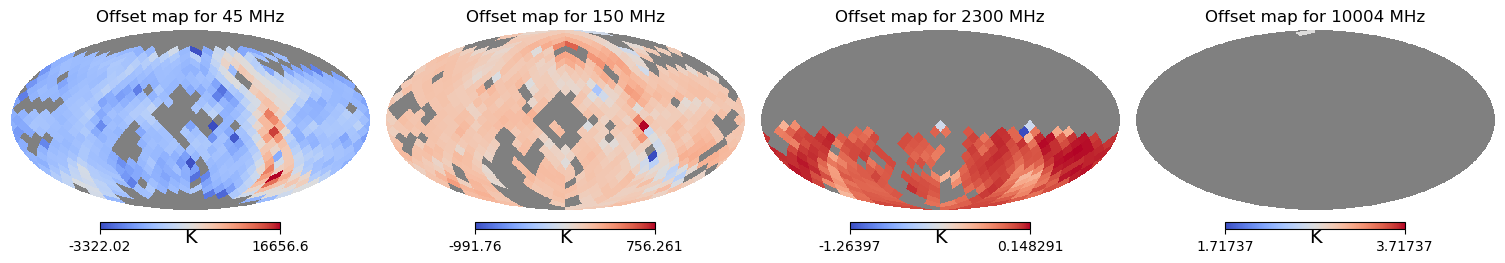

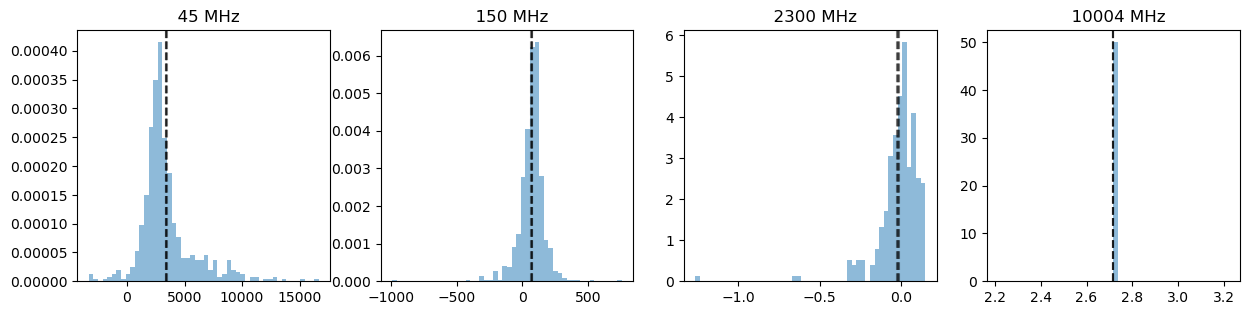

In [6]:
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

j=0
pl.figure(figsize=(15, 10))

for k, offset, error_offset  , offset_map  in results:
    hp.mollview(offset_map, title=f"Offset map for {k} MHz", unit=f"{maps[k].unit}" , cmap='coolwarm',
                sub=(4,4,j+1))
    j+=1
    
offset_file = open(output_dir+'/offset_coarse_south.txt', 'w')

pl.figure(figsize=(15, 15))
j=0
for k, offset, error_offset  , offset_map  in results:
    offset_file.write("%f %f % f\n" %(k, offset.value, error_offset))
    pl.subplot(4, 4, j+1)
    pl.title(f"  {k} MHz") 
    pl.hist(np.ma.masked_invalid(offset_map ).data.flatten(), bins=50, label=f"{k} MHz", alpha=0.5, density=True)
    pl.axvline ( offset.value,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offset.value -error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offset.value +error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    j+=1

offset_file.close()

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_11006/3813029826.py:6: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True ,  min=1,  max=10    )


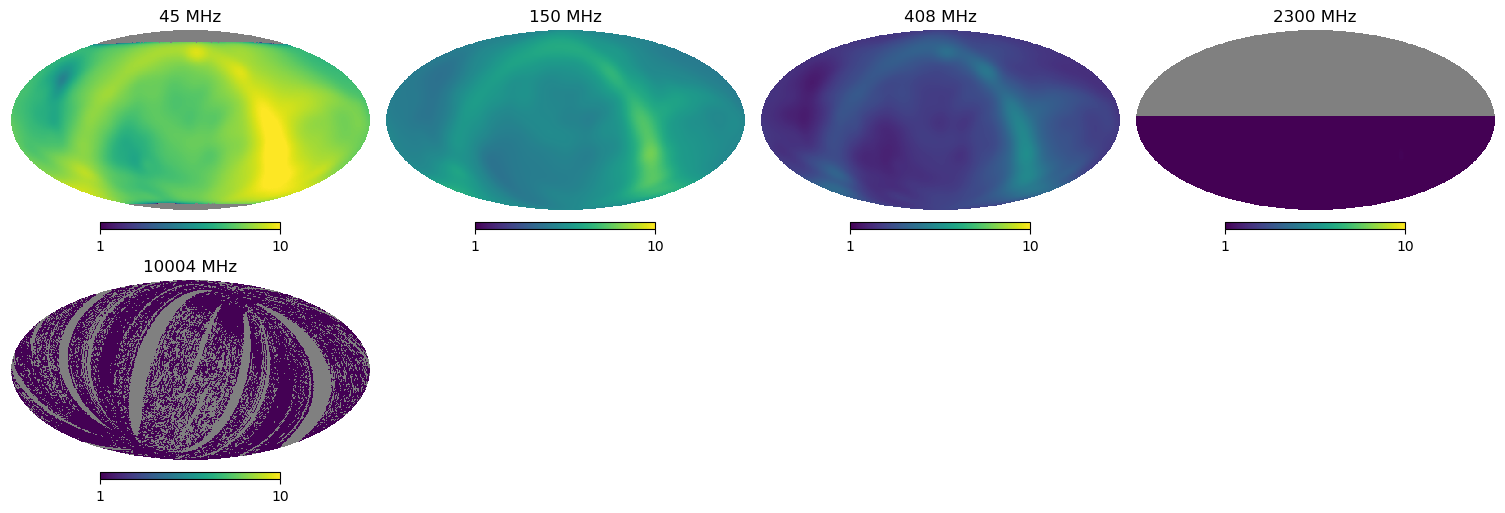

In [7]:
pl.figure(figsize=(15,10)) 

j=0
for fr,m in maps.items():
     
    hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True ,  min=1,  max=10    )
    
    j+=1



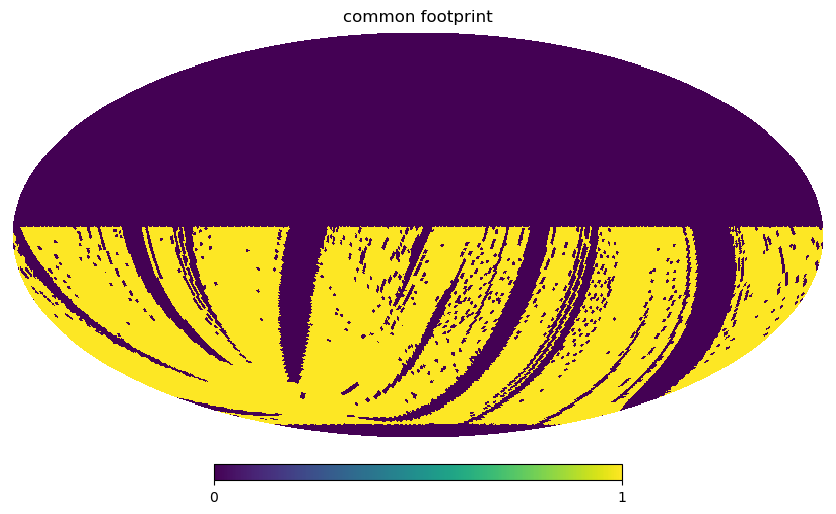

In [8]:
#chipass_nans = np.ma.masked_invalid(maps[1400] ).mask   
jonas_nans = np.ma.masked_invalid(maps[2300]).mask
mu_mask=  np.ma.masked_invalid(maps[45]).mask
juno_mask=  np.ma.masked_invalid(maps[10004]).mask
common_footprint0 =  np.logical_and(~jonas_nans , ~mu_mask)  
common_footprint =  np.logical_and(common_footprint0, ~juno_mask)  
hp.mollview(common_footprint, title='common footprint' ) 


In [9]:
hp.write_map(
    f"{output_dir}/common_footprint_southern.fits",
    common_footprint.astype(np.float32),
    overwrite=True
)

setting the output map dtype to [dtype('float32')]


In [10]:
fstring="COM_CompMap_freefree-commander_0256_R2.00.fits"
try :
    print(f"reading {fstring} ")
    tmp=  hp.read_map(filename=f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )  
except FileNotFoundError: 
    filename = wget.download( f"http://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=COM_CompMap_freefree-commander_0256_R2.00.fits" , out ="../lwa_data")
    tmp=  hp.read_map(f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )
 
planck_em = tmp[0]* u.cm**-6 *u.pc
planck_te = tmp [1]*u.K 

fstring = "EM_mean_std.fits"
try :
    print(f"reading {fstring} ")
    hust=  hp.read_map(filename=f"../lwa_data/{fstring}"   )  
except FileNotFoundError: 
    filename = wget.download( f"https://zenodo.org/records/10523170/files/EM_mean_std.fits" , out ="../lwa_data")
    hust =  hp.read_map(f"../lwa_data/{fstring}"    )
hust *= u.cm**-6 *u.pc

reading COM_CompMap_freefree-commander_0256_R2.00.fits 
reading EM_mean_std.fits 


In [11]:

Tff = lambda Te , nu,EM  : Te * (1.0 - np.exp(-tauff(Te,nu, EM ))) 
tauff = lambda Te,nu , EM : 0.05468 *   (Te.value )**-1.5 * (nu.value )**-2 *EM.value   *gff (Te,nu) 
Zi =1 
gff =lambda Te ,nu :  np.log (np.exp(1.0) +np.exp (5.960 -np.sqrt(3)/np.pi *np.log (Zi *nu.to(u.GHz).value *(Te/(1e4*u.K)  )**-1.5  )) )  

free ={} 
for fr in maps.keys() : 
    tmp = Tff(Te=planck_te, nu=(fr*u.MHz).to(u.GHz), EM=planck_em  )
    tmp = hp.smoothing(tmp   , fwhm=pl.sqrt(fwhms[45]**2 -  1*u.deg **2 ).to(u.rad).value  )
    free[fr]= rotate_map(tmp , 'G', 'C')* (maps[45].unit)  



/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_11006/3810562272.py:5: RuntimeWarning: invalid value encountered in log10
  hp.mollview(  pl.log10((m .value  -free[fr ].value  )  )   ,  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True ,  coord='CG',   )


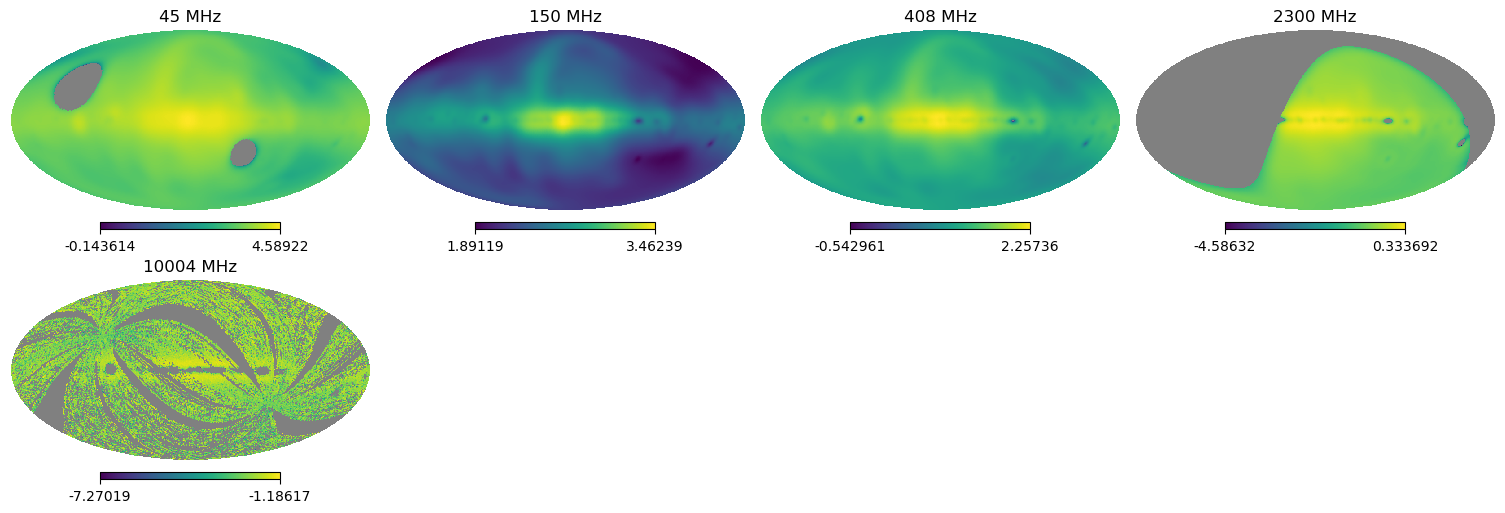

In [12]:
pl.figure(figsize=(15,10)) 
j=0
for fr,m in maps.items():
     
    hp.mollview(  pl.log10((m .value  -free[fr ].value  )  )   ,  title=f'{fr} MHz'  , sub=(4,4,1+j) , notext=True ,  coord='CG',   )
    
    j+=1

pl.show() 

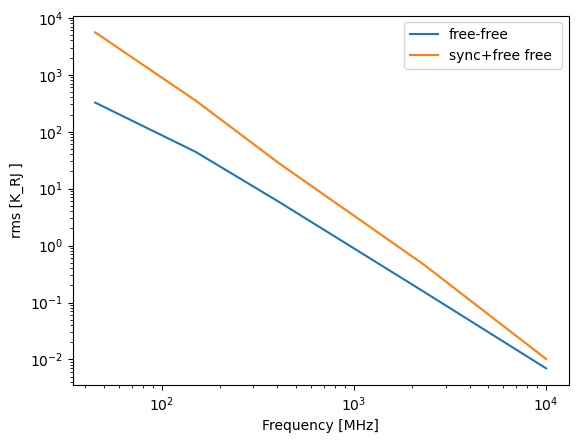

In [13]:
rmsf =np.array( [ np.nanstd(f .value)    for f in free.values() ] ) 
rmsm = np.array( [ np.nanstd(m .value)    for m in maps.values() ] ) 
pl.loglog( freqs, rmsf  ,label='free-free' ,)
pl.loglog( freqs, rmsm  , label='sync+free free ', )

pl.legend()
pl.xlabel('Frequency [MHz]')
pl.ylabel('rms [K_RJ ]')  
pl.show() 


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_11006/3112238713.py:8: RuntimeWarning: invalid value encountered in log
  ydat = pl.log(pixvals / pixvals[ifreq])
/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_11006/3112238713.py:61: RuntimeWarning: invalid value encountered in log
  ydat = pl.log(pixvals / pixvals[ifreq])


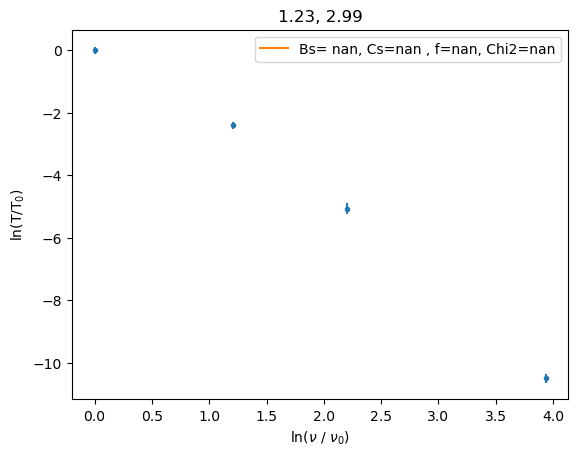

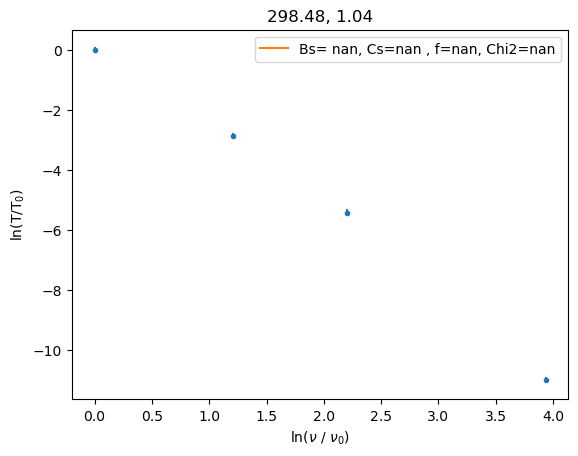

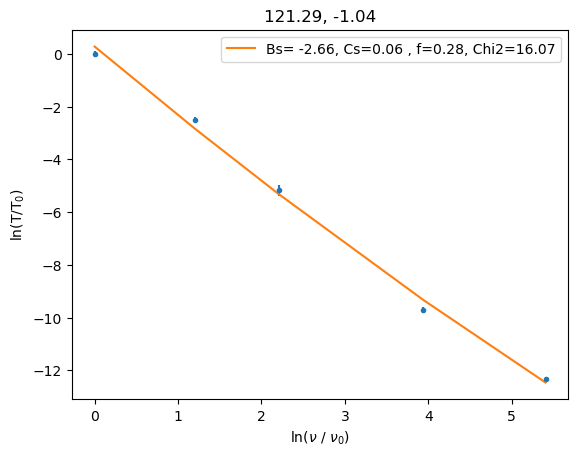

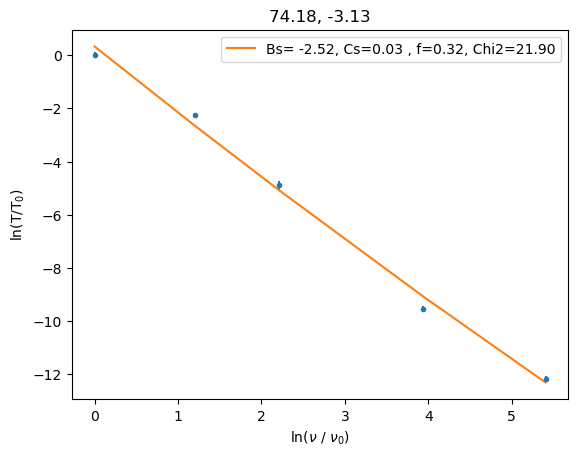

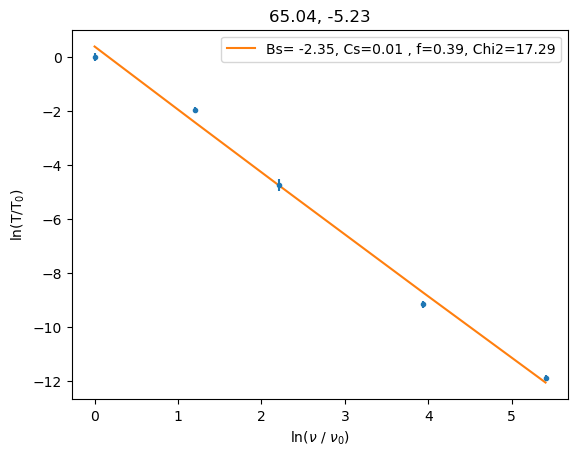

In [14]:
def fitting_beta_curvature(X, beta, cs, const):
    return beta * X + cs * X * X + const

def process_pixel(ipix, return_errors=False):
    ifreq = np.argmin(np.abs(freqs - 45))
    pixvals = np.array([(m[ipix].value - free[k][ipix].value) for k, m in maps.items()])
    nans = np.isnan(pixvals)
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq])
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    p0 = np.array([-3, -0.1, 1])
    ret = np.full(p0.size + 2, np.nan)
    ret[0] = ipix
    errs = np.full(p0.size, np.nan)
    pcov = np.zeros((3, 3)) + np.nan
    if nans.sum():
        return (ret, errs) 
    try:
        popt, pcov = curve_fit(fitting_beta_curvature, xdat, ydat, sigma=logyerr, p0=p0)
        ret[-1] = np.sum(((ydat - fitting_beta_curvature(xdat, *popt)) / logyerr) ** 2) / (xdat.size - p0.size)
        ret[1:-1] = popt
        errs = np.sqrt(np.diag(pcov))
        return ret, errs 
    except Exception:
        return ret, errs 

pixel_select = np.arange(npix)[common_footprint]
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)

error_betamap = np.full(hp.nside2npix(nside), np.nan)
error_csmap = np.full(hp.nside2npix(nside), np.nan)
error_fmap = np.full(hp.nside2npix(nside), np.nan)

jj = 0
for ipix in pixel_select[::1000]:
    # Use return_errors=True for error estimation, False for covariance
    fitted_params, error_params = process_pixel(ipix, return_errors=True)
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] = fitted_params[3]
    chisquare_map[ipix] = fitted_params[-1]
    error_betamap[ipix] = error_params[0]
    error_csmap[ipix] = error_params[1]
    error_fmap[ipix] = error_params[2]
    pixvals = np.array([ (m[ipix].value - free[k][ipix ] .value)  for k, m in maps.items() ])
    nans = np.isnan(pixvals)
    ifreq = np.argmin(np.abs(freqs - 45))
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq] )

    #data errors are calibration errors plus offset errors
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    if jj%10==0:
        pl.figure() 
        lon,lat =hp.pix2ang(ipix=ipix, nside=hp.get_nside(maps[45]), lonlat=True) 
        pl.title( f"{lon:.2f}, {lat:.2f}" )
        pl.errorbar ( xdat ,  ydat ,
                     yerr= logyerr  ,
                        fmt='.' )
         
        pl.plot( xdat ,  fitting_beta_curvature( xdat , *fitted_params[1:-1] ),  
                label =f'Bs= {fitted_params[1]:.2f}, Cs={fitted_params[2]:.2f} , f={fitted_params[3]:.2f}, Chi2={fitted_params[-1]:.2f}' ) 
                #, Bf={fitted_params[4]:.2f}, 

        #pl.semilogx() 
        #pl.loglog() 
        pl.legend()
        pl.xlabel(r"ln($\nu$ / $\nu_{0}$)")
        pl.ylabel(r"ln(T/T$_{0}$)") 
    jj+=1 
    if jj== 50: break

In [15]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

    
# Initialize shared arrays
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
betafmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)
error_betamap = np.full(hp.nside2npix(nside), np.nan)
error_csmap = np.full(hp.nside2npix(nside), np.nan)
error_fmap = np.full(hp.nside2npix(nside), np.nan)



# Use ThreadPoolExecutor for parallel processing
with ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_pixel, pixel_select), total=len(pixel_select)))

for fitted_params, errs  in results:
    ipix = int(fitted_params[0])  # Ensure ipix is an integer
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] =   fitted_params[3]
    #betafmap[ipix] = fitted_params[4]

    chisquare_map[ipix] = fitted_params[-1]
    error_betamap[ipix] = errs[0]
    error_csmap[ipix] = errs[1]
    error_fmap[ipix] = errs[2]

    


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_11006/3112238713.py:8: RuntimeWarning: invalid value encountered in log
  ydat = pl.log(pixvals / pixvals[ifreq])
100%|██████████| 304663/304663 [00:02<00:00, 138087.81it/s]


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_11006/380064113.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


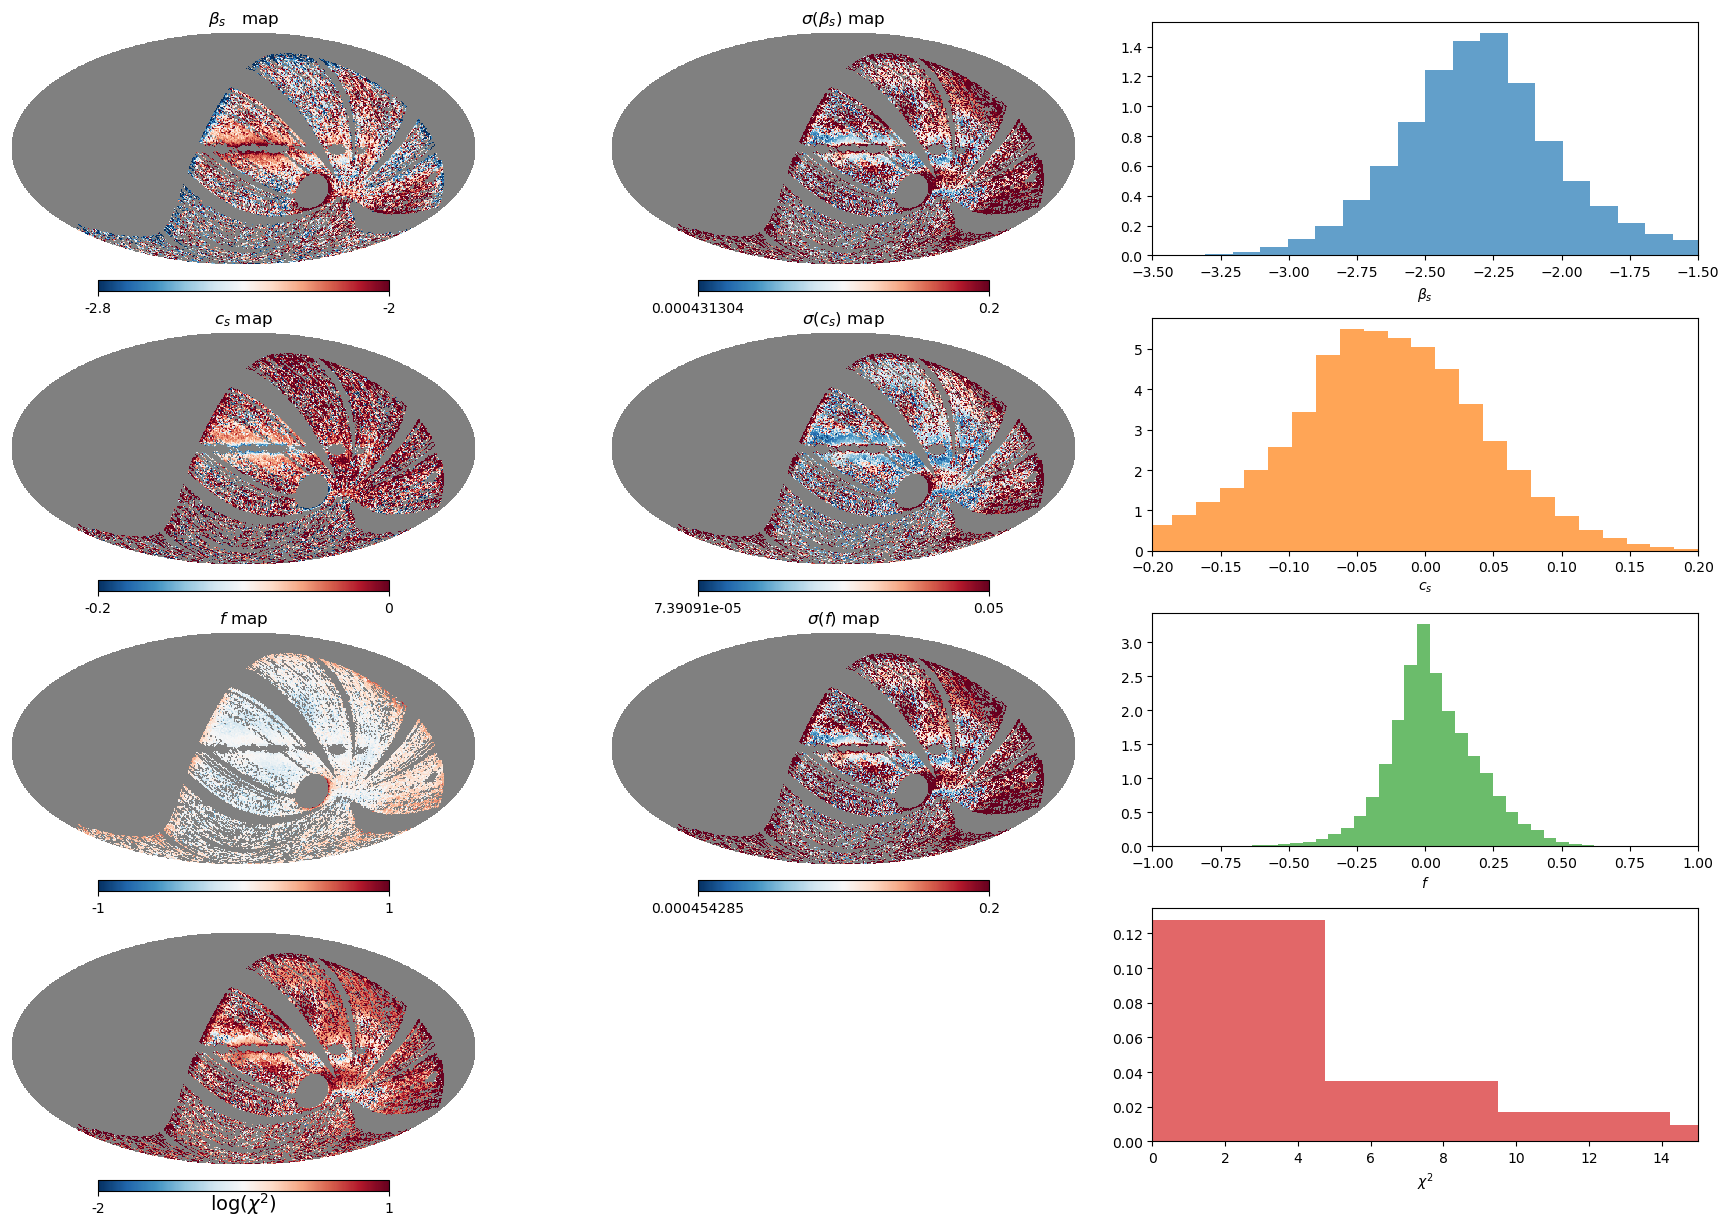

In [16]:
fig, axes = pl.subplots(4, 3, figsize=(18, 12))

# 1st row: betamap
hp.mollview(betamap, sub=(4, 3, 1), min=-2.8, max=-2.,  cmap='RdBu_r', coord='CG', notext=True,  title=r'$\beta_s$   map' )
hp.mollview(error_betamap, sub=(4, 3, 2), max=0.2,  cmap='RdBu_r', coord='CG', notext=True, fig=fig, title=r'$\sigma(\beta_s)$ map')
axes[0, 2].hist(betamap[~np.isnan(betamap)], bins=50, density=True, color='C0', alpha=0.7)
axes[0, 2].set_xlabel(r'$\beta_s$')
#axes[0, 2].set_ylabel('Density')
axes[0, 2].set_xlim( [-3.5, -1.5])


# 2nd row: csmap

hp.mollview(csmap, sub=(4, 3, 4), min=-0.2, max=0.,  cmap='RdBu_r', coord='CG', notext=True, fig=fig, title=r'$c_s$ map')

hp.mollview(error_csmap, sub=(4, 3, 5), max=0.05,  cmap='RdBu_r', coord='CG', notext=True, fig=fig, title=r'$\sigma(c_s)$ map')

axes[1, 2].hist(csmap[~np.isnan(csmap)], bins=50, density=True, color='C1', alpha=0.7)
axes[1, 2].set_xlabel(r'$c_s$')
axes[1, 2].set_xlim( [-.2, .2 ])

#axes[1, 2].set_ylabel('Density')

# 3rd row: fmap
hp.mollview(fmap, sub=(4, 3, 7),  cmap='RdBu_r',min=-1,max=1, coord='CG', notext=True, fig=fig, title=r'$f$ map')
hp.mollview(error_fmap, sub=(4, 3, 8), max=0.2,  cmap='RdBu_r', coord='CG', notext=True, fig=fig, title=r'$\sigma(f)$ map')

axes[2, 2].hist(fmap[~np.isnan(fmap)], bins=50, density=True, color='C2', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[2, 2].set_xlabel(r'$f$')
axes[2, 2].set_xlim( [-1, 1 ])

hp.mollview(np.log10(chisquare_map)   , sub=(4,3,10) ,  min=-2 ,max=1,    unit=r'$\log (\chi^2)$',cmap='RdBu_r',coord='CG',notext=True , title=' ' ) 
axes[3, 2].hist(chisquare_map[~np.isnan(chisquare_map)], bins=50, density=True, color='C3', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[3, 2].set_xlabel( r'$ \chi^2$')
axes[3, 2].set_xlim( [0,15 ])

# Remove empty axes from the figure
for ax_row in axes:
    for ax in ax_row:
        if not ax.has_data():
            fig.delaxes(ax)
pl.tight_layout()

In [17]:
# Save all maps into a single HEALPix FITS file
hp.write_map(
    f"{output_dir}/bfit_maps_south_11.fits",
    [betamap, csmap, fmap, error_betamap , error_csmap, error_fmap , chisquare_map ],
    column_names=["BETAMAP", "CSMAP", "FMAP","BETAMAP_ERR", "CSMAP_ERR", "FMAP_ERR" ,"CHISQUARE"  ],
    overwrite=True,
    dtype=np.float32
)
